# Final V2 Restart-Safe NILM Demonstration

This notebook loads the frozen V2 package and performs inference
without training, tuning or model selection. It is intentionally
non-interactive so **Run all** completes without waiting for input.

Edit only `DEMO_HOUSE`, `DEMO_START` and `DEMO_END` in the first code
cell. Houses 1 and 2 are restricted to their held-out temporal-test
periods; House 5 is restricted to the external-evaluation period.

## 1. Configuration, dependencies and Drive mount

In [1]:
# ================================================================
# FINAL V2 RESTART-SAFE NILM DEMONSTRATION
# ================================================================
# Development houses: Houses 1 and 2
# External unseen property: House 5
# Input: aggregate mains-derived causal features only
# No training, tuning, model selection, or replacement occurs here.
# ================================================================

from pathlib import Path
import glob
import json
import gc
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score,
)

from IPython.display import display

warnings.filterwarnings("ignore")

# Edit only these four values before running the notebook.
DEMO_HOUSE = 1
DEMO_START = "2016-07-30 00:00:00"
DEMO_END = "2016-07-31 00:00:00"
MAX_DEMO_DAYS = 7
SHOW_PACKAGE_DETAILS = False

def detail_log(*args, **kwargs):
    if SHOW_PACKAGE_DETAILS:
        print(*args, **kwargs)

def detail_display(value):
    if SHOW_PACKAGE_DETAILS:
        display(value)

In [2]:
# ================================================================
# 1. MOUNT GOOGLE DRIVE
# ================================================================

try:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    else:
        print("Google Drive is already mounted.")
except Exception as error:
    print("Drive mount message:", error)

Mounted at /content/drive


In [3]:
# ================================================================
# 2. LOCATE FINAL REPRODUCIBLE MODEL PACKAGE
# ================================================================

package_patterns = [
    "/content/drive/MyDrive/dissertation/"
    "cross_house_transfer_v1_2026_07/evaluation/"
    "final_reproducible_model_v2",

    "/content/drive/.shortcut-targets-by-id/*/dissertation/"
    "cross_house_transfer_v1_2026_07/evaluation/"
    "final_reproducible_model_v2",

    "/content/google_drive_recovery_*/MyDrive/dissertation/"
    "cross_house_transfer_v1_2026_07/evaluation/"
    "final_reproducible_model_v2",
]

package_candidates = []

for pattern in package_patterns:
    package_candidates.extend(
        Path(path) for path in glob.glob(pattern)
        if Path(path).is_dir()
    )

if not package_candidates:
    package_candidates = [
        path for path in Path("/content").rglob("final_reproducible_model_v2")
        if path.is_dir()
    ]

assert package_candidates, (
    "The final_reproducible_model_v2 package could not be found."
)

PACKAGE_ROOT = sorted(
    package_candidates,
    key=lambda path: len(str(path))
)[0]

EXPERIMENT_ROOT = PACKAGE_ROOT.parent.parent

detail_log("\nFinal reproducible package:")
detail_log(PACKAGE_ROOT)

detail_log("\nExperiment root:")
detail_log(EXPERIMENT_ROOT)

In [4]:
# ================================================================
# 3. GENERAL FILE HELPERS
# ================================================================

def resolve_saved_path(saved_path):
    """Repair paths after a Drive remount or shortcut-path change."""

    if saved_path is None or pd.isna(saved_path):
        return None

    candidate = Path(str(saved_path))

    if candidate.exists():
        return candidate

    marker = "cross_house_transfer_v1_2026_07"

    if marker in str(candidate):
        suffix = str(candidate).split(marker, 1)[1].lstrip("/\\")
        repaired = EXPERIMENT_ROOT / suffix

        if repaired.exists():
            return repaired

    matches = list(PACKAGE_ROOT.rglob(candidate.name))

    if not matches:
        matches = list(EXPERIMENT_ROOT.rglob(candidate.name))

    return matches[0] if matches else None


def normalise_columns(frame):
    frame = frame.copy()
    frame.columns = [
        str(column).strip().lower()
        for column in frame.columns
    ]
    return frame


def read_small_table(path):
    try:
        if path.suffix.lower() == ".csv":
            return normalise_columns(pd.read_csv(path))

        if path.suffix.lower() == ".json":
            with open(path, "r", encoding="utf-8") as file:
                content = json.load(file)

            if isinstance(content, list):
                return normalise_columns(pd.DataFrame(content))

            if isinstance(content, dict):
                for value in content.values():
                    if isinstance(value, list):
                        candidate = pd.DataFrame(value)

                        if not candidate.empty:
                            return normalise_columns(candidate)

                try:
                    return normalise_columns(pd.DataFrame([content]))
                except Exception:
                    return None
    except Exception:
        return None

    return None


def parquet_columns(path):
    try:
        import pyarrow.parquet as pq
        return list(pq.ParquetFile(str(path)).schema.names)
    except Exception:
        try:
            return list(pd.read_parquet(path).columns)
        except Exception:
            return []

In [5]:
# ================================================================
# 4. DISCOVER THE FROZEN POLICY
# ================================================================

policy_candidates = []

for path in list(PACKAGE_ROOT.rglob("*.csv")) + list(
    PACKAGE_ROOT.rglob("*.json")
):
    frame = read_small_table(path)

    if frame is None or frame.empty:
        continue

    required = {"category", "model_family"}

    if not required.issubset(frame.columns):
        continue

    model_column = None

    for column in ["selected_model", "model"]:
        if column in frame.columns:
            model_column = column
            break

    if model_column is None:
        continue

    categories = set(
        frame["category"].astype(str).str.lower().unique()
    )

    expected_categories = {
        "kettle",
        "cold_appliance",
        "dishwasher",
        "laundry_appliance",
        "microwave",
    }

    if not expected_categories.issubset(categories):
        continue

    score = 0
    name = path.name.lower()

    if "policy" in name:
        score += 20

    if "reproducible" in name:
        score += 20

    if "final" in name:
        score += 10

    if len(frame) == 5:
        score += 20

    policy_candidates.append(
        (score, path, frame, model_column)
    )

assert policy_candidates, "Could not locate the frozen model policy."

policy_candidates.sort(key=lambda item: item[0], reverse=True)

_, POLICY_PATH, policy_df, policy_model_column = policy_candidates[0]

policy_df = policy_df.copy()
policy_df["category"] = (
    policy_df["category"].astype(str).str.lower()
)

if policy_model_column != "selected_model":
    policy_df = policy_df.rename(
        columns={policy_model_column: "selected_model"}
    )

policy_df = (
    policy_df[
        policy_df["category"].isin(expected_categories)
    ]
    .drop_duplicates("category")
    .reset_index(drop=True)
)

assert len(policy_df) == 5

detail_log("\nFrozen validation-selected policy:")
detail_display(
    policy_df[
        [
            column for column in [
                "category",
                "source_experiment",
                "model_family",
                "selected_model",
                "probability_threshold",
                "power_multiplier",
            ]
            if column in policy_df.columns
        ]
    ]
)

In [6]:
# ================================================================
# 4B. LOAD THE FROZEN EXPERIMENT 4 CAUSAL POST-PROCESSING POLICY
# ================================================================

POSTPROCESSING_POLICY_PATH = (
    PACKAGE_ROOT
    / "config"
    / "final_causal_postprocessing_policy.csv"
)

assert POSTPROCESSING_POLICY_PATH.exists(), (
    "Missing frozen Experiment 4 policy:\n"
    f"{POSTPROCESSING_POLICY_PATH}"
)

postprocessing_policy_df = normalise_columns(
    pd.read_csv(POSTPROCESSING_POLICY_PATH)
)
postprocessing_policy_df["category"] = (
    postprocessing_policy_df["category"].astype(str).str.lower()
)
postprocessing_policy_df = (
    postprocessing_policy_df[
        postprocessing_policy_df["category"].isin(expected_categories)
    ]
    .drop_duplicates("category", keep="last")
    .reset_index(drop=True)
)

assert set(postprocessing_policy_df["category"]) == expected_categories
assert len(postprocessing_policy_df) == 5

detail_log("\nFrozen causal post-processing policy:")
detail_display(
    postprocessing_policy_df[
        [
            column for column in [
                "category",
                "processor_mode",
                "power_scale",
                "entry_factor",
                "exit_factor",
                "ema_alpha",
                "confirm_on_rows",
                "confirm_off_rows",
                "minimum_on_rows",
                "decision",
            ]
            if column in postprocessing_policy_df.columns
        ]
    ]
)

In [7]:
# ================================================================
# 5. DISCOVER THE FROZEN ARTIFACT MANIFEST
# ================================================================

artifact_candidates = []

for path in list(PACKAGE_ROOT.rglob("*.csv")) + list(
    PACKAGE_ROOT.rglob("*.json")
):
    frame = read_small_table(path)

    if frame is None or frame.empty:
        continue

    if not {"category", "artifact_role"}.issubset(frame.columns):
        continue

    path_column = next(
        (
            column for column in [
                "frozen_path",
                "artifact_path",
                "model_path",
                "path",
            ]
            if column in frame.columns
        ),
        None,
    )

    if path_column is None:
        continue

    score = 0
    name = path.name.lower()

    if "artifact" in name:
        score += 20

    if "manifest" in name:
        score += 20

    if "final" in name or "reproducible" in name:
        score += 10

    artifact_candidates.append(
        (score, path, frame, path_column)
    )

assert artifact_candidates, (
    "Could not locate the final frozen-artifact manifest."
)

artifact_candidates.sort(
    key=lambda item: item[0],
    reverse=True
)

_, ARTIFACT_MANIFEST_PATH, artifact_df, artifact_path_column = (
    artifact_candidates[0]
)

artifact_df = artifact_df.copy()
artifact_df["category"] = (
    artifact_df["category"].astype(str).str.lower()
)
artifact_df["artifact_role"] = (
    artifact_df["artifact_role"].astype(str).str.lower()
)


def load_frozen_artifact(category, role):
    rows = artifact_df[
        (artifact_df["category"] == category)
        & (artifact_df["artifact_role"] == role)
    ]

    assert not rows.empty, (
        f"Missing frozen artifact: {category}/{role}"
    )

    saved_path = rows.iloc[0][artifact_path_column]
    resolved_path = resolve_saved_path(saved_path)

    assert resolved_path is not None and resolved_path.exists(), (
        f"Could not resolve frozen artifact path for "
        f"{category}/{role}: {saved_path}"
    )

    estimator = joblib.load(resolved_path)

    if isinstance(estimator, dict):
        for key in [
            "estimator",
            "model",
            "classifier",
            "regressor",
        ]:
            if key in estimator:
                estimator = estimator[key]
                break

    return estimator, resolved_path

In [8]:
# ================================================================
# 6. LOAD ALL FROZEN MODELS
# ================================================================

models = {}
artifact_paths = {}

for _, policy_row in policy_df.iterrows():
    category = policy_row["category"]
    family = str(policy_row["model_family"]).lower()

    if "hurdle" in family:
        classifier, classifier_path = load_frozen_artifact(
            category,
            "on_off_classifier",
        )

        regressor, regressor_path = load_frozen_artifact(
            category,
            "active_power_regressor",
        )

        models[category] = {
            "type": "hurdle",
            "classifier": classifier,
            "regressor": regressor,
        }

        artifact_paths[category] = {
            "classifier": classifier_path,
            "regressor": regressor_path,
        }

    else:
        estimator, estimator_path = load_frozen_artifact(
            category,
            "selected_model",
        )

        models[category] = {
            "type": "direct",
            "estimator": estimator,
        }

        artifact_paths[category] = {
            "estimator": estimator_path,
        }

In [9]:
# ================================================================
# 7. RECOVER THE ORIGINAL 24-FEATURE INTERFACE
# ================================================================

fallback_feature_columns = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

FEATURE_COLUMNS = None

for bundle in models.values():
    estimators = []

    if bundle["type"] == "direct":
        estimators.append(bundle["estimator"])
    else:
        estimators.extend(
            [bundle["classifier"], bundle["regressor"]]
        )

    for estimator in estimators:
        if hasattr(estimator, "feature_names_in_"):
            columns = list(estimator.feature_names_in_)

            if len(columns) == 24:
                FEATURE_COLUMNS = columns
                break

    if FEATURE_COLUMNS is not None:
        break

if FEATURE_COLUMNS is None:
    FEATURE_COLUMNS = fallback_feature_columns

assert len(FEATURE_COLUMNS) == 24

detail_log("\nRecovered model feature interface:")
detail_log(f"{len(FEATURE_COLUMNS)} causal aggregate-mains features")

In [10]:
# ================================================================
# 8. PERMITTED DEMONSTRATION PERIODS
# ================================================================

PERMITTED_PERIODS = {
    1: {
        "start": pd.Timestamp("2016-06-04 23:19:40"),
        "end": pd.Timestamp("2017-04-26 17:32:40"),
        "default_start": pd.Timestamp("2016-07-30 00:00:00"),
        "default_end": pd.Timestamp("2016-07-31 00:00:00"),
        "label": "HELD-OUT SOURCE TEMPORAL TEST",
    },
    2: {
        "start": pd.Timestamp("2013-08-24 07:28:10"),
        "end": pd.Timestamp("2013-10-10 05:15:50"),
        "default_start": pd.Timestamp("2013-09-01 00:00:00"),
        "default_end": pd.Timestamp("2013-09-02 00:00:00"),
        "label": "HELD-OUT SOURCE TEMPORAL TEST",
    },
    5: {
        "start": pd.Timestamp("2014-06-29 16:23:40"),
        "end": pd.Timestamp("2014-11-13 17:52:20"),
        "default_start": pd.Timestamp("2014-10-20 00:00:00"),
        "default_end": pd.Timestamp("2014-10-21 00:00:00"),
        "label": "EXTERNAL PROPERTY EVALUATION",
    },
}

detail_log("\nPermitted demonstration periods:")

for house_number, information in PERMITTED_PERIODS.items():
    detail_log(
        f"House {house_number}: "
        f"{information['start']} to {information['end']}"
    )

In [11]:
# ================================================================
# 9. DEMONSTRATION CONFIGURATION
# ================================================================

HOUSE_NUMBER = int(DEMO_HOUSE)
assert HOUSE_NUMBER in [1, 2, 5], "DEMO_HOUSE must be 1, 2 or 5."

period_information = PERMITTED_PERIODS[HOUSE_NUMBER]
START_TIME = pd.Timestamp(DEMO_START)
END_TIME = pd.Timestamp(DEMO_END)

assert START_TIME < END_TIME
assert START_TIME >= period_information["start"]
assert END_TIME <= period_information["end"]
assert END_TIME - START_TIME <= pd.Timedelta(days=MAX_DEMO_DAYS)

START_SECOND = int(START_TIME.timestamp())
END_SECOND = int(END_TIME.timestamp())

configuration_df = pd.DataFrame({
    "setting": ["House", "Evaluation role", "Start", "End (exclusive)"],
    "value": [HOUSE_NUMBER, period_information["label"], START_TIME, END_TIME],
})
detail_display(configuration_df)

In [12]:
# ================================================================
# 10. TIMESTAMP UTILITIES
# ================================================================

def to_integer_seconds(values):
    series = pd.Series(values)

    if pd.api.types.is_datetime64_any_dtype(series):
        return (
            series.astype("int64") // 1_000_000_000
        ).astype("int64")

    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.notna().any():
        median_value = float(
            numeric.dropna().abs().median()
        )

        if median_value > 1e17:       # nanoseconds
            numeric = numeric / 1e9
        elif median_value > 1e14:     # microseconds
            numeric = numeric / 1e6
        elif median_value > 1e11:     # milliseconds
            numeric = numeric / 1e3

        return numeric.round().astype("Int64")

    parsed = pd.to_datetime(series, errors="coerce")

    return (
        parsed.astype("int64") // 1_000_000_000
    ).astype("Int64")


def timestamp_column(columns):
    for candidate in [
        "timestamp_unix",
        "timestamp",
        "timestamp_s",
        "time",
    ]:
        if candidate in columns:
            return candidate

    raise AssertionError(
        f"No timestamp column found. Columns: {list(columns)}"
    )


def read_interval(path, required_columns):
    available_columns = parquet_columns(path)
    time_column = timestamp_column(available_columns)

    columns = list(
        dict.fromkeys([time_column] + required_columns)
    )

    frame = pd.read_parquet(path, columns=columns)
    frame["_timestamp_second"] = to_integer_seconds(
        frame[time_column]
    )

    frame = frame[
        (frame["_timestamp_second"] >= START_SECOND)
        & (frame["_timestamp_second"] < END_SECOND)
    ].copy()

    frame = frame.dropna(
        subset=["_timestamp_second"]
    )

    frame["_timestamp_second"] = (
        frame["_timestamp_second"].astype("int64")
    )

    frame = (
        frame.sort_values("_timestamp_second")
        .drop_duplicates("_timestamp_second")
        .reset_index(drop=True)
    )

    return frame

In [13]:
# ================================================================
# 11. DISCOVER FEATURE DATASET
# ================================================================

def discover_feature_path(house_number):
    exact_paths = []

    if house_number in [1, 2]:
        exact_paths.append(
            EXPERIMENT_ROOT
            / "processed"
            / "source_mains_features"
            / f"house_{house_number}_test_mains_features.parquet"
        )

    candidates = [
        path for path in exact_paths
        if path.exists()
    ]

    for path in EXPERIMENT_ROOT.rglob("*.parquet"):
        path_text = str(path).lower()

        if "improvement_experiment_3" in path_text:
            continue

        columns = parquet_columns(path)

        if not set(FEATURE_COLUMNS).issubset(columns):
            continue

        score = 0

        if f"house_{house_number}" in path_text:
            score += 30

        if "mains_features" in path_text:
            score += 30

        if house_number in [1, 2] and "test" in path_text:
            score += 20

        if house_number == 5 and "external_test" in path_text:
            score += 30

        if "validation" in path_text or "train" in path_text:
            score -= 30

        candidates.append((score, path))

    direct_candidates = [
        candidate for candidate in candidates
        if isinstance(candidate, Path)
    ]

    if direct_candidates:
        return direct_candidates[0]

    scored_candidates = [
        candidate for candidate in candidates
        if isinstance(candidate, tuple)
    ]

    assert scored_candidates, (
        f"No feature dataset found for House {house_number}."
    )

    scored_candidates.sort(
        key=lambda item: item[0],
        reverse=True
    )

    return scored_candidates[0][1]


FEATURE_PATH = discover_feature_path(HOUSE_NUMBER)

detail_log("\nFeature dataset:")
detail_log(FEATURE_PATH)

feature_frame = read_interval(
    FEATURE_PATH,
    FEATURE_COLUMNS,
)

assert not feature_frame.empty, (
    "No feature rows were found inside the requested period."
)

assert feature_frame[FEATURE_COLUMNS].notna().all().all()
assert np.isfinite(
    feature_frame[FEATURE_COLUMNS].to_numpy(
        dtype=np.float64
    )
).all()

detail_log(
    f"Loaded {len(feature_frame):,} causal "
    f"aggregate-mains feature rows."
)

In [14]:
# ================================================================
# 12. DISCOVER PAIRWISE TARGET DATASETS
# ================================================================

csv_manifest_paths = [
    path for path in EXPERIMENT_ROOT.rglob("*.csv")
    if path.stat().st_size < 20_000_000
    and "improvement_experiment_3" not in str(path).lower()
]

manifest_cache = {}


def target_column(columns):
    for candidate in [
        "target_w",
        "y_true_w",
        "appliance_w",
        "actual_w",
    ]:
        if candidate in columns:
            return candidate

    return None


def discover_target_path(house_number, category):
    possible_paths = []

    for manifest_path in csv_manifest_paths:
        try:
            if manifest_path not in manifest_cache:
                manifest_cache[manifest_path] = normalise_columns(
                    pd.read_csv(manifest_path)
                )

            manifest = manifest_cache[manifest_path]
        except Exception:
            continue

        if "category" not in manifest.columns:
            continue

        category_rows = manifest[
            manifest["category"].astype(str).str.lower()
            == category
        ].copy()

        if category_rows.empty:
            continue

        if "house" in category_rows.columns:
            acceptable_houses = {
                str(house_number),
                f"house_{house_number}",
            }

            filtered = category_rows[
                category_rows["house"]
                .astype(str)
                .str.lower()
                .isin(acceptable_houses)
            ]

            if not filtered.empty:
                category_rows = filtered

        if "house_number" in category_rows.columns:
            filtered = category_rows[
                pd.to_numeric(
                    category_rows["house_number"],
                    errors="coerce",
                )
                == house_number
            ]

            if not filtered.empty:
                category_rows = filtered

        if "split" in category_rows.columns:
            split_text = (
                category_rows["split"]
                .astype(str)
                .str.lower()
            )

            if house_number in [1, 2]:
                filtered = category_rows[
                    split_text.str.contains("test")
                ]
            else:
                filtered = category_rows[
                    split_text.str.contains("external")
                    | split_text.str.contains("test")
                ]

            if not filtered.empty:
                category_rows = filtered

        path_column = next(
            (
                column for column in [
                    "output_path",
                    "target_path",
                    "path",
                ]
                if column in category_rows.columns
            ),
            None,
        )

        if path_column is None:
            continue

        for value in category_rows[path_column]:
            resolved = resolve_saved_path(value)

            if resolved is None or not resolved.exists():
                continue

            columns = parquet_columns(resolved)

            if target_column(columns) is None:
                continue

            score = 0
            text = str(resolved).lower()

            if category in text:
                score += 20

            if f"house_{house_number}" in text:
                score += 20

            if house_number == 5 and "external" in text:
                score += 20

            if house_number in [1, 2] and "test" in text:
                score += 10

            possible_paths.append((score, resolved))

    if not possible_paths:
        for path in EXPERIMENT_ROOT.rglob("*.parquet"):
            path_text = str(path).lower()

            if "improvement_experiment_3" in path_text:
                continue

            columns = parquet_columns(path)

            if target_column(columns) is None:
                continue

            score = 0

            if category in path_text:
                score += 30

            if f"house_{house_number}" in path_text:
                score += 20

            if house_number in [1, 2] and "test" in path_text:
                score += 20

            if house_number == 5 and "external" in path_text:
                score += 30

            if "train" in path_text or "validation" in path_text:
                score -= 40

            possible_paths.append((score, path))

    assert possible_paths, (
        f"No pairwise target dataset found for "
        f"House {house_number}/{category}."
    )

    possible_paths.sort(
        key=lambda item: item[0],
        reverse=True
    )

    return possible_paths[0][1]

In [15]:
# ================================================================
# 12B. FROZEN CAUSAL POST-PROCESSING
# ================================================================

def numeric_policy_value(row, column, default):
    if column not in row.index:
        return default

    try:
        value = float(row[column])
        return value if np.isfinite(value) else default
    except Exception:
        return default


def apply_stateful_processor(
    prediction,
    timestamps,
    mains_w,
    event_threshold_w,
    policy_row,
):
    power_scale = numeric_policy_value(policy_row, "power_scale", 1.0)
    entry_factor = numeric_policy_value(policy_row, "entry_factor", 0.50)
    exit_factor = numeric_policy_value(policy_row, "exit_factor", 0.25)
    ema_alpha = numeric_policy_value(policy_row, "ema_alpha", 1.0)
    confirm_on_rows = max(1, int(numeric_policy_value(policy_row, "confirm_on_rows", 1)))
    confirm_off_rows = max(1, int(numeric_policy_value(policy_row, "confirm_off_rows", 1)))
    minimum_on_rows = max(1, int(numeric_policy_value(policy_row, "minimum_on_rows", 1)))

    output = np.zeros(len(prediction), dtype=np.float64)
    entry_threshold = event_threshold_w * entry_factor
    exit_threshold = event_threshold_w * exit_factor

    state_on = False
    on_confirmation = 0
    off_confirmation = 0
    on_age = 0
    ema_value = 0.0

    for index, current_prediction in enumerate(prediction):
        current_prediction = float(current_prediction)
        new_segment = (
            index == 0
            or timestamps[index] - timestamps[index - 1] != 10
        )

        if new_segment:
            state_on = False
            on_confirmation = 0
            off_confirmation = 0
            on_age = 0
            ema_value = current_prediction
        else:
            ema_value = (
                ema_alpha * current_prediction
                + (1.0 - ema_alpha) * ema_value
            )

        if not state_on:
            if ema_value >= entry_threshold:
                on_confirmation += 1
            else:
                on_confirmation = 0

            if on_confirmation >= confirm_on_rows:
                state_on = True
                on_age = 1
                off_confirmation = 0
            else:
                on_age = 0
        else:
            on_age += 1

            if ema_value < exit_threshold:
                off_confirmation += 1
            else:
                off_confirmation = 0

            if (
                off_confirmation >= confirm_off_rows
                and on_age >= minimum_on_rows
            ):
                state_on = False
                on_confirmation = 0
                off_confirmation = 0
                on_age = 0

        if state_on:
            output[index] = ema_value * power_scale

    output = np.nan_to_num(output, nan=0.0, posinf=0.0, neginf=0.0)
    return np.minimum(np.clip(output, 0.0, None), mains_w)


def apply_frozen_postprocessing(
    category,
    incumbent_prediction,
    timestamps,
    mains_w,
):
    policy_row = postprocessing_policy_df.loc[
        postprocessing_policy_df["category"] == category
    ].iloc[0]

    processor_mode = str(
        policy_row.get("processor_mode", "incumbent")
    ).strip().lower()
    power_scale = numeric_policy_value(policy_row, "power_scale", 1.0)

    if "incumbent" in processor_mode:
        output = incumbent_prediction.copy()
    elif "pointwise" in processor_mode:
        output = incumbent_prediction * power_scale
    elif "stateful" in processor_mode:
        output = apply_stateful_processor(
            prediction=incumbent_prediction,
            timestamps=timestamps,
            mains_w=mains_w,
            event_threshold_w=EVENT_THRESHOLDS_W[category],
            policy_row=policy_row,
        )
    else:
        raise AssertionError(
            f"Unknown frozen processor mode for {category}: {processor_mode}"
        )

    output = np.nan_to_num(output, nan=0.0, posinf=0.0, neginf=0.0)
    return np.minimum(np.clip(output, 0.0, None), mains_w)

In [16]:
# ================================================================
# 13. FROZEN-MODEL INFERENCE
# ================================================================

EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

CATEGORY_LABELS = {
    "kettle": "Kettle",
    "cold_appliance": "Cold appliance",
    "dishwasher": "Dishwasher",
    "laundry_appliance": "Laundry appliance",
    "microwave": "Microwave",
}

X = feature_frame[FEATURE_COLUMNS].copy()
timestamps = feature_frame["_timestamp_second"].to_numpy()
mains_w = np.clip(
    feature_frame["mains_w"].to_numpy(dtype=np.float64),
    0.0,
    None,
)

raw_predictions = {}
actual_targets = {}
target_paths = {}

for _, policy_row in policy_df.iterrows():
    category = policy_row["category"]
    bundle = models[category]

    print(
        f"Predicting {CATEGORY_LABELS[category]}: "
        f"{policy_row['model_family']} / "
        f"{policy_row['selected_model']}"
    )

    if bundle["type"] == "direct":
        prediction = bundle["estimator"].predict(X)
        prediction = np.asarray(
            prediction,
            dtype=np.float64,
        ).reshape(-1)

    else:
        classifier = bundle["classifier"]
        regressor = bundle["regressor"]

        probability_matrix = classifier.predict_proba(X)

        classes = list(classifier.classes_)

        positive_index = (
            classes.index(1)
            if 1 in classes
            else probability_matrix.shape[1] - 1
        )

        probability_on = probability_matrix[:, positive_index]

        probability_threshold = float(
            policy_row.get("probability_threshold", 0.5)
        )

        power_multiplier = float(
            policy_row.get("power_multiplier", 1.0)
        )

        gate_is_open = (
            probability_on >= probability_threshold
        )

        predicted_log_power = np.asarray(
            regressor.predict(X),
            dtype=np.float64,
        ).reshape(-1)

        predicted_active_power = np.expm1(
            np.clip(predicted_log_power, -20.0, 20.0)
        )

        prediction = np.where(
            gate_is_open,
            predicted_active_power * power_multiplier,
            0.0,
        )

    incumbent_prediction = np.minimum(
        np.clip(
            np.nan_to_num(
                prediction,
                nan=0.0,
                posinf=0.0,
                neginf=0.0,
            ),
            0.0,
            None,
        ),
        mains_w,
    )

    raw_predictions[category] = apply_frozen_postprocessing(
        category=category,
        incumbent_prediction=incumbent_prediction,
        timestamps=timestamps,
        mains_w=mains_w,
    )

    target_path = discover_target_path(
        HOUSE_NUMBER,
        category,
    )

    target_paths[category] = target_path
    target_columns = parquet_columns(target_path)
    y_column = target_column(target_columns)

    target_frame = read_interval(
        target_path,
        [y_column],
    )

    target_series = pd.Series(
        np.clip(
            target_frame[y_column].to_numpy(
                dtype=np.float64
            ),
            0.0,
            None,
        ),
        index=target_frame["_timestamp_second"],
    )

    target_series = target_series.groupby(
        level=0
    ).mean()

    actual_targets[category] = target_series.reindex(
        timestamps
    ).to_numpy(dtype=np.float64)

    del target_frame, target_series
    gc.collect()

Predicting Cold appliance: Classical ML / Random Forest
Predicting Dishwasher: Two-stage Hurdle Model / Classifier + Active-Power Regressor
Predicting Kettle: Classical ML / Decision Tree
Predicting Laundry appliance: Two-stage Hurdle Model / Classifier + Active-Power Regressor
Predicting Microwave: Two-stage Hurdle Model / Classifier + Active-Power Regressor


In [17]:
# ================================================================
# 14. JOINT PHYSICAL PROJECTION
# ================================================================

category_order = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

prediction_matrix = np.column_stack(
    [raw_predictions[category] for category in category_order]
)

raw_prediction_sum = prediction_matrix.sum(axis=1)

projection_scale = np.ones(len(prediction_matrix))

excess_mask = (
    raw_prediction_sum > mains_w
) & (raw_prediction_sum > 0)

projection_scale[excess_mask] = (
    mains_w[excess_mask]
    / raw_prediction_sum[excess_mask]
)

projected_matrix = (
    prediction_matrix * projection_scale[:, None]
)

projected_predictions = {
    category: projected_matrix[:, index]
    for index, category in enumerate(category_order)
}

rows_adjusted_percentage = (
    100.0 * excess_mask.mean()
)

In [18]:
# ================================================================
# 15. CALCULATE APPLIANCE METRICS
# ================================================================

sampling_seconds = 10.0
metric_rows = []

for category in category_order:
    actual = actual_targets[category]
    predicted = projected_predictions[category]

    valid = np.isfinite(actual) & np.isfinite(predicted)

    assert valid.any(), (
        f"No observed target values for {category} "
        f"inside the requested period."
    )

    actual_valid = actual[valid]
    predicted_valid = predicted[valid]

    threshold = EVENT_THRESHOLDS_W[category]

    actual_state = actual_valid >= threshold
    predicted_state = predicted_valid >= threshold

    actual_energy_kwh = (
        actual_valid.sum()
        * sampling_seconds
        / 3_600_000
    )

    predicted_energy_kwh = (
        predicted_valid.sum()
        * sampling_seconds
        / 3_600_000
    )

    sae_pct = (
        abs(predicted_energy_kwh - actual_energy_kwh)
        / actual_energy_kwh
        * 100.0
        if actual_energy_kwh > 0
        else np.nan
    )

    metric_rows.append(
        {
            "appliance": CATEGORY_LABELS[category],
            "category": category,
            "model_family": policy_df.loc[
                policy_df["category"] == category,
                "model_family",
            ].iloc[0],
            "model": policy_df.loc[
                policy_df["category"] == category,
                "selected_model",
            ].iloc[0],
            "postprocessor": postprocessing_policy_df.loc[
                postprocessing_policy_df["category"] == category,
                "processor_mode",
            ].iloc[0],
            "rows": int(valid.sum()),
            "actual_energy_kwh": actual_energy_kwh,
            "predicted_energy_kwh": predicted_energy_kwh,
            "sae_pct": sae_pct,
            "mae_w": mean_absolute_error(
                actual_valid,
                predicted_valid,
            ),
            "rmse_w": mean_squared_error(
                actual_valid,
                predicted_valid,
            ) ** 0.5,
            "precision": precision_score(
                actual_state,
                predicted_state,
                zero_division=0,
            ),
            "recall": recall_score(
                actual_state,
                predicted_state,
                zero_division=0,
            ),
            "f1_score": f1_score(
                actual_state,
                predicted_state,
                zero_division=0,
            ),
        }
    )

appliance_results_df = pd.DataFrame(metric_rows)

mains_energy_kwh = (
    mains_w.sum()
    * sampling_seconds
    / 3_600_000
)

actual_selected_energy_kwh = (
    appliance_results_df["actual_energy_kwh"].sum()
)

predicted_selected_energy_kwh = (
    appliance_results_df["predicted_energy_kwh"].sum()
)

selected_sae_pct = (
    abs(
        predicted_selected_energy_kwh
        - actual_selected_energy_kwh
    )
    / actual_selected_energy_kwh
    * 100.0
)

kpi_df = pd.DataFrame(
    {
        "metric": [
            "Mains energy (kWh)",
            "Actual five-category energy (kWh)",
            "Predicted five-category energy (kWh)",
            "Five-category SAE (%)",
            "Mean appliance MAE (W)",
            "Mean appliance F1 score",
            "Rows jointly physically adjusted (%)",
        ],
        "value": [
            mains_energy_kwh,
            actual_selected_energy_kwh,
            predicted_selected_energy_kwh,
            selected_sae_pct,
            appliance_results_df["mae_w"].mean(),
            appliance_results_df["f1_score"].mean(),
            rows_adjusted_percentage,
        ],
    }
)

In [19]:
# ================================================================
# 16. DISPLAY RESULTS
# ================================================================

detail_log("\n" + "=" * 78)
detail_log("FINAL V2 FROZEN-MODEL NILM INFERENCE DEMONSTRATION")
detail_log(f"Evaluation: {period_information['label']}")
detail_log(f"House: house_{HOUSE_NUMBER}")
detail_log(
    f"Period: {START_TIME} to {END_TIME} "
    "(end exclusive)"
)
detail_log(f"Feature rows: {len(feature_frame):,}")
detail_log("=" * 78)

detail_log("\nDeployment KPIs:")
display(kpi_df.round(4))

detail_log("\nAppliance-level results:")
display(
    appliance_results_df[
        [
            "appliance",
            "model_family",
            "model",
            "postprocessor",
            "actual_energy_kwh",
            "predicted_energy_kwh",
            "sae_pct",
            "mae_w",
            "f1_score",
        ]
    ].round(4)
)

,metric,value
0,Mains energy (kWh),9.4183
1,Actual five-category energy (kWh),3.7494
2,Predicted five-category energy (kWh),3.3668
3,Five-category SAE (%),10.2066
4,Mean appliance MAE (W),37.4928
5,Mean appliance F1 score,0.3780
6,Rows jointly physically adjusted (%),1.1111


,appliance,model_family,model,postprocessor,actual_energy_kwh,predicted_energy_kwh,sae_pct,mae_w,f1_score
0,Kettle,Classical ML,Decision Tree,stateful,0.2573,0.2996,16.4588,7.4100,0.8065
1,Cold appliance,Classical ML,Random Forest,incumbent,1.2078,1.0066,16.6582,27.7809,0.7544
2,Dishwasher,Two-stage Hurdle Model,Classifier + Active-Power Regressor,incumbent,0.0240,1.5097,6187.4774,63.8442,0.0000
3,Laundry appliance,Two-stage Hurdle Model,Classifier + Active-Power Regressor,stateful,2.2364,0.4377,80.4287,82.7107,0.3289
4,Microwave,Two-stage Hurdle Model,Classifier + Active-Power Regressor,pointwise,0.0240,0.1131,372.3401,5.7182,0.0000


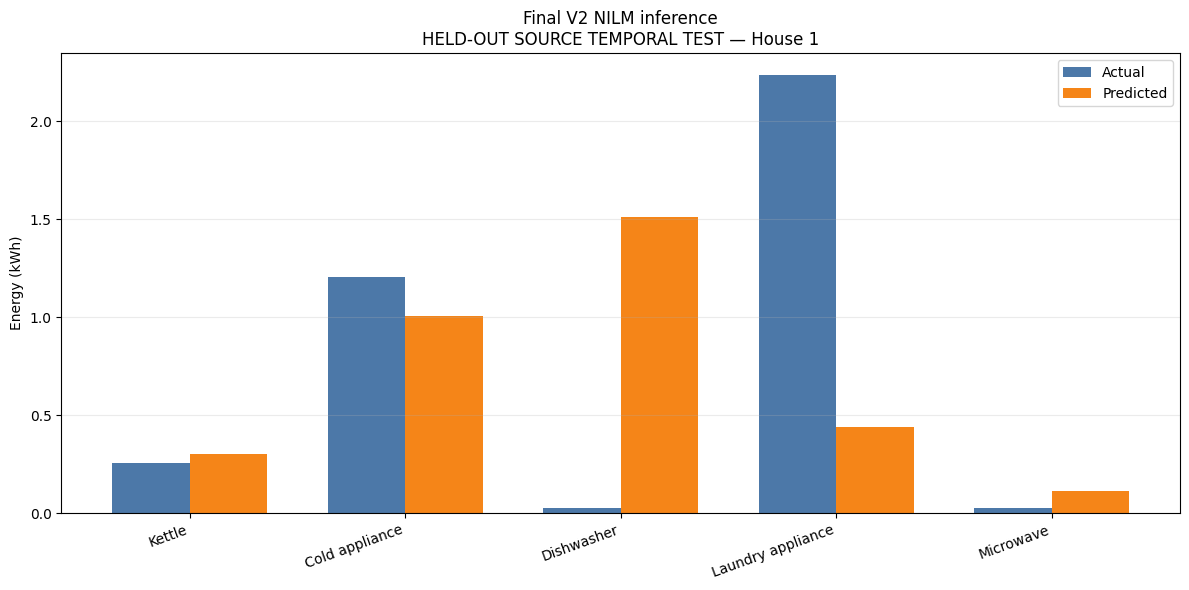

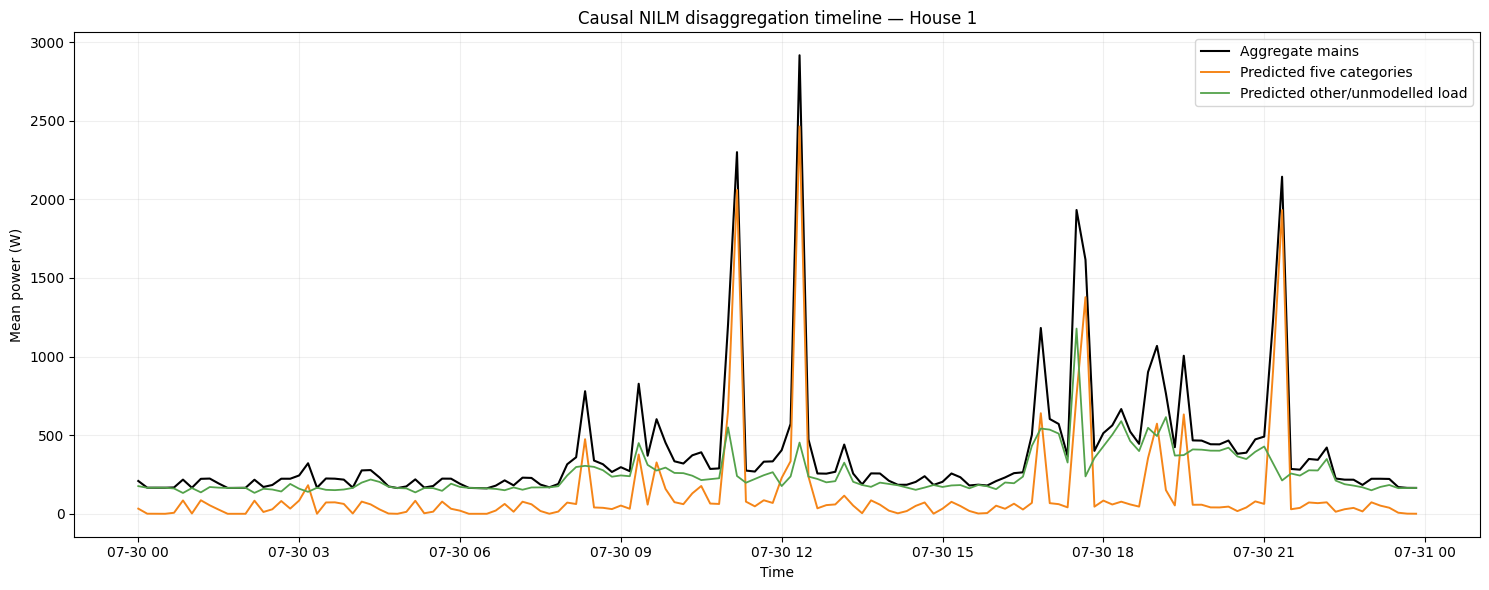

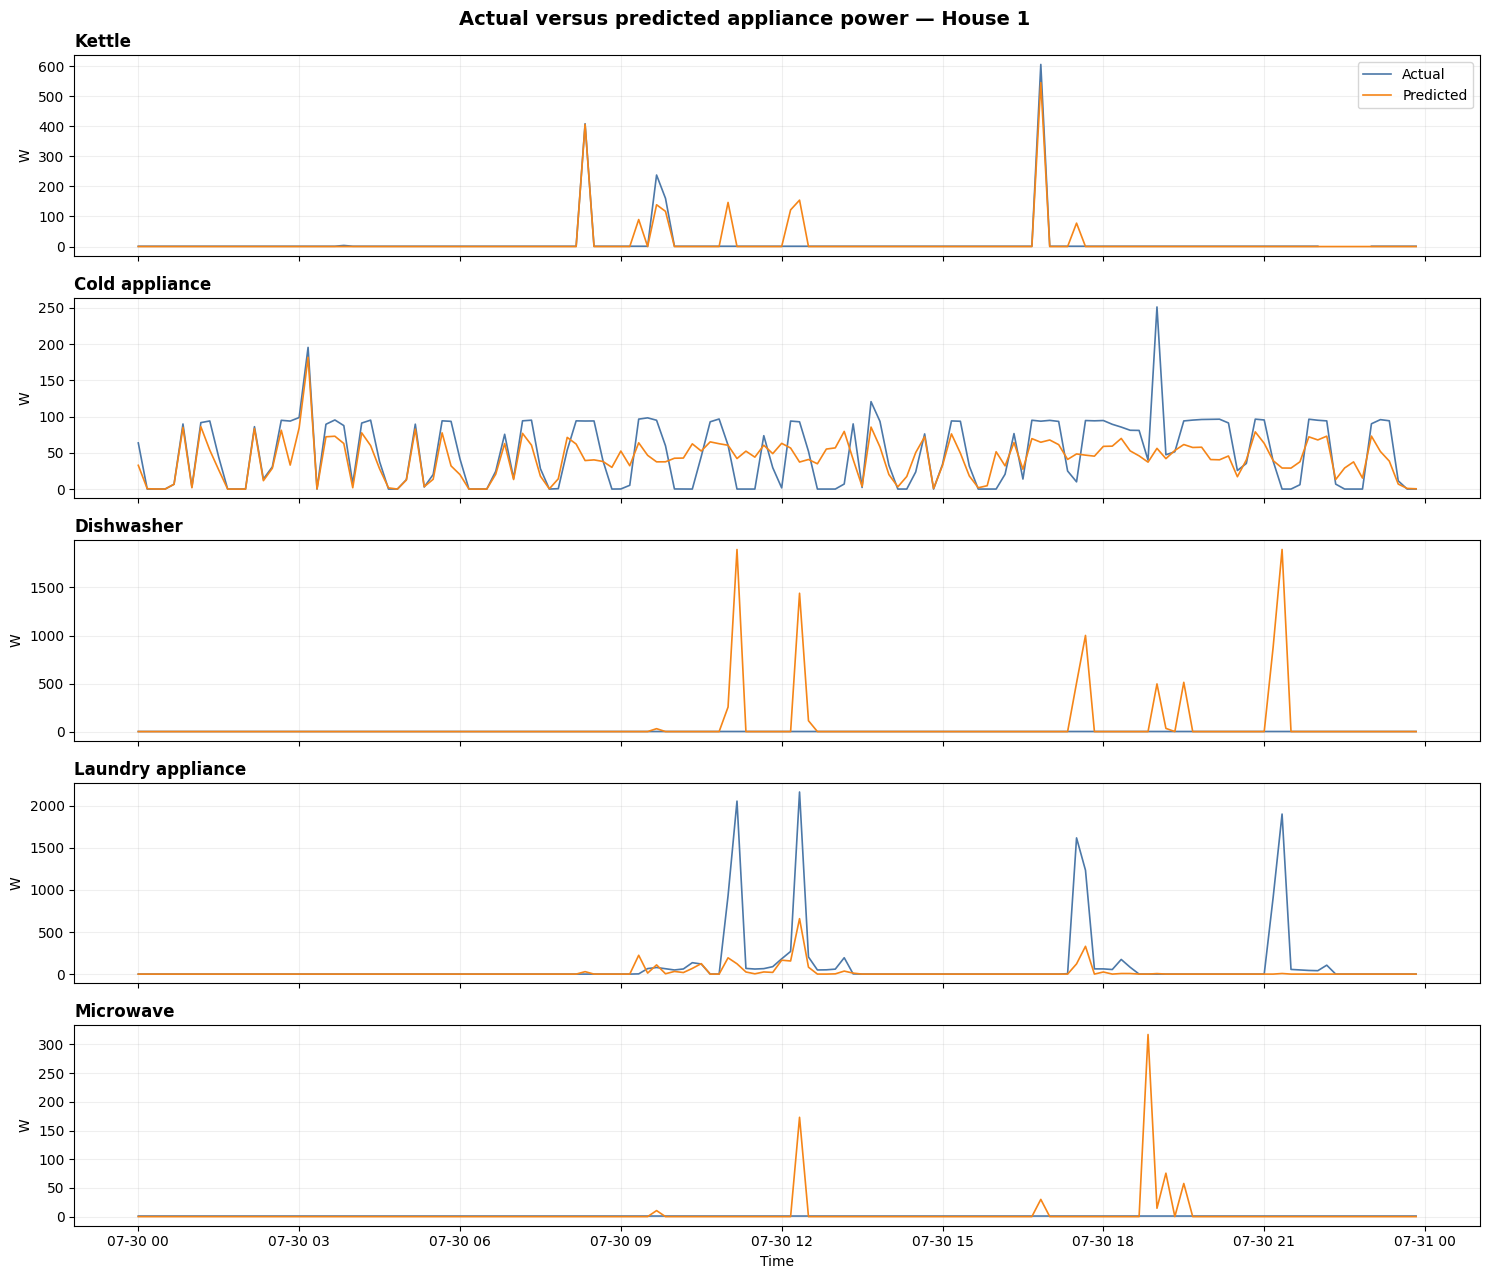

In [20]:
# ================================================================
# 17. SAVE RESULTS AND GENERATE FIGURES
# ================================================================

OUTPUT_DIRECTORY = PACKAGE_ROOT / "demo_outputs"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

safe_start = START_TIME.strftime("%Y%m%d_%H%M%S")
safe_end = END_TIME.strftime("%Y%m%d_%H%M%S")

output_stem = (
    f"house_{HOUSE_NUMBER}_{safe_start}_{safe_end}"
)

appliance_csv_path = (
    OUTPUT_DIRECTORY
    / f"{output_stem}_appliance_results.csv"
)

kpi_csv_path = (
    OUTPUT_DIRECTORY
    / f"{output_stem}_kpis.csv"
)

appliance_results_df.to_csv(
    appliance_csv_path,
    index=False,
)

kpi_df.to_csv(
    kpi_csv_path,
    index=False,
)


# Actual-versus-predicted appliance energy figure
figure_1, axis_1 = plt.subplots(figsize=(12, 6))

positions = np.arange(len(appliance_results_df))
width = 0.36

axis_1.bar(
    positions - width / 2,
    appliance_results_df["actual_energy_kwh"],
    width,
    label="Actual",
    color="#4C78A8",
)

axis_1.bar(
    positions + width / 2,
    appliance_results_df["predicted_energy_kwh"],
    width,
    label="Predicted",
    color="#F58518",
)

axis_1.set_xticks(positions)
axis_1.set_xticklabels(
    appliance_results_df["appliance"],
    rotation=20,
    ha="right",
)

axis_1.set_ylabel("Energy (kWh)")
axis_1.set_title(
    "Final V2 NILM inference\n"
    f"{period_information['label']} — House {HOUSE_NUMBER}"
)
axis_1.legend()
axis_1.grid(axis="y", alpha=0.25)

figure_1.tight_layout()

energy_figure_path = (
    OUTPUT_DIRECTORY
    / f"{output_stem}_energy_disaggregation.png"
)

figure_1.savefig(
    energy_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Causal disaggregation timeline
predicted_selected_w = projected_matrix.sum(axis=1)
predicted_other_w = np.clip(
    mains_w - predicted_selected_w,
    0.0,
    None,
)

timeline_df = pd.DataFrame(
    {
        "timestamp": pd.to_datetime(
            timestamps,
            unit="s",
        ),
        "aggregate_mains": mains_w,
        "predicted_five_categories": predicted_selected_w,
        "predicted_other_load": predicted_other_w,
    }
).set_index("timestamp")

timeline_csv_path = OUTPUT_DIRECTORY / f"{output_stem}_timeline.csv"

timeline_df.to_csv(timeline_csv_path)


timeline_plot_df = timeline_df.resample("10min").mean()

figure_2, axis_2 = plt.subplots(figsize=(15, 6))

axis_2.plot(
    timeline_plot_df.index,
    timeline_plot_df["aggregate_mains"],
    color="black",
    linewidth=1.5,
    label="Aggregate mains",
)

axis_2.plot(
    timeline_plot_df.index,
    timeline_plot_df["predicted_five_categories"],
    color="#F58518",
    linewidth=1.4,
    label="Predicted five categories",
)

axis_2.plot(
    timeline_plot_df.index,
    timeline_plot_df["predicted_other_load"],
    color="#54A24B",
    linewidth=1.3,
    label="Predicted other/unmodelled load",
)

axis_2.set_title(
    "Causal NILM disaggregation timeline — "
    f"House {HOUSE_NUMBER}"
)

axis_2.set_xlabel("Time")
axis_2.set_ylabel("Mean power (W)")
axis_2.legend()
axis_2.grid(alpha=0.2)

figure_2.tight_layout()

timeline_figure_path = (
    OUTPUT_DIRECTORY
    / f"{output_stem}_timeline.png"
)

figure_2.savefig(
    timeline_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()



# Category-level diagnostic timeline
figure_3, axes_3 = plt.subplots(len(category_order), 1, figsize=(15, 13), sharex=True)

timeline_index = pd.to_datetime(timestamps, unit="s")
for axis, category in zip(axes_3, category_order):
    actual_series = pd.Series(actual_targets[category], index=timeline_index).resample("10min").mean()
    predicted_series = pd.Series(projected_predictions[category], index=timeline_index).resample("10min").mean()
    axis.plot(actual_series.index, actual_series, color="#4C78A8", linewidth=1.2, label="Actual")
    axis.plot(predicted_series.index, predicted_series, color="#F58518", linewidth=1.2, label="Predicted")
    axis.set_ylabel("W")
    axis.set_title(CATEGORY_LABELS[category], loc="left", weight="bold")
    axis.grid(alpha=0.2)

axes_3[0].legend(loc="upper right")
axes_3[-1].set_xlabel("Time")
figure_3.suptitle(f"Actual versus predicted appliance power — House {HOUSE_NUMBER}", fontsize=14, weight="bold")
figure_3.tight_layout()

category_timeline_path = OUTPUT_DIRECTORY / f"{output_stem}_category_timelines.png"
figure_3.savefig(category_timeline_path, dpi=300, bbox_inches="tight")
plt.show()

detail_log("\nSaved category timelines:")
detail_log(category_timeline_path)

In [21]:
# ================================================================
# 18. FINAL AUDIT
# ================================================================

saved_outputs_df = pd.DataFrame(
    {
        "artifact": [
            "Appliance metrics",
            "Deployment KPIs",
            "Energy comparison figure",
            "Aggregate timeline figure",
            "Category timeline figure",
            "Timeline data",
        ],
        "path": [
            appliance_csv_path,
            kpi_csv_path,
            energy_figure_path,
            timeline_figure_path,
            category_timeline_path,
            timeline_csv_path,
        ],
    }
)
saved_outputs_df["path"] = saved_outputs_df["path"].astype(str)

print("FINAL V2 RESTART-SAFE NILM DEMONSTRATION: PASS")
display(saved_outputs_df)

FINAL V2 RESTART-SAFE NILM DEMONSTRATION: PASS


,artifact,path
0,Appliance metrics,/content/drive/MyDrive/dissertation/cross_hous...
1,Deployment KPIs,/content/drive/MyDrive/dissertation/cross_hous...
2,Energy comparison figure,/content/drive/MyDrive/dissertation/cross_hous...
3,Aggregate timeline figure,/content/drive/MyDrive/dissertation/cross_hous...
4,Category timeline figure,/content/drive/MyDrive/dissertation/cross_hous...
5,Timeline data,/content/drive/MyDrive/dissertation/cross_hous...
